<a href="https://colab.research.google.com/github/rishith2209/MACHINE-LEARNING/blob/main/LAB7_KNN_AP23110011392.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:

!pip install gdown


In [46]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2

Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 22.5MB/s]


In [47]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
df = pd.read_csv("multiclass.csv")
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Region            440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
 7   class             440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Missing values (isnull):
 Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
class               0
dtype: int64

Missing values (isna):
 Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
class       

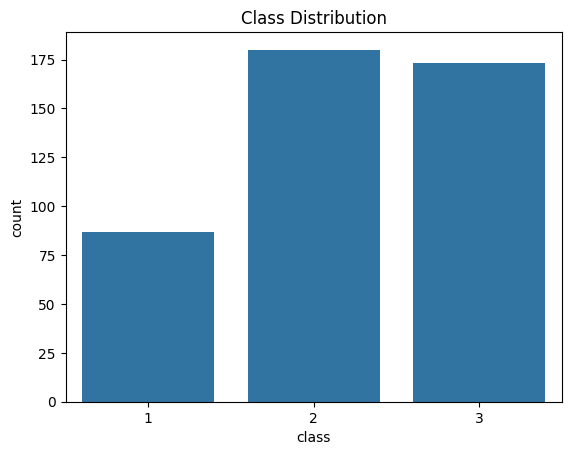

In [49]:
# Dataset overview
df.info()

# Missing values check
print("\nMissing values (isnull):\n", df.isnull().sum())
print("\nMissing values (isna):\n", df.isna().sum())

# Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Confirm cleanup
print("\nRemaining missing values:", df.isnull().sum().sum())

# Class distribution imbalance check
print("\nClass distribution:\n", df['class'].value_counts())
sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.show()

# Features & labels
X = df.drop("class", axis=1)
y = df["class"]

# Scale features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [50]:
import numpy as np
from collections import Counter

# Euclidean distance function
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# KNN from scratch
class KNN_Scratch:
    def __init__(self, k=17):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Train & Test Scratch KNN
knn_scratch = KNN_Scratch(k=17)
knn_scratch.fit(X_train, y_train)
y_pred_scratch = knn_scratch.predict(X_test)

# Accuracy
scratch_acc = np.mean(y_pred_scratch == y_test)
print("Scratch KNN Accuracy:", scratch_acc)


Scratch KNN Accuracy: 0.9659090909090909


 Best k = 11 with Cross-Validation Accuracy = 0.8864


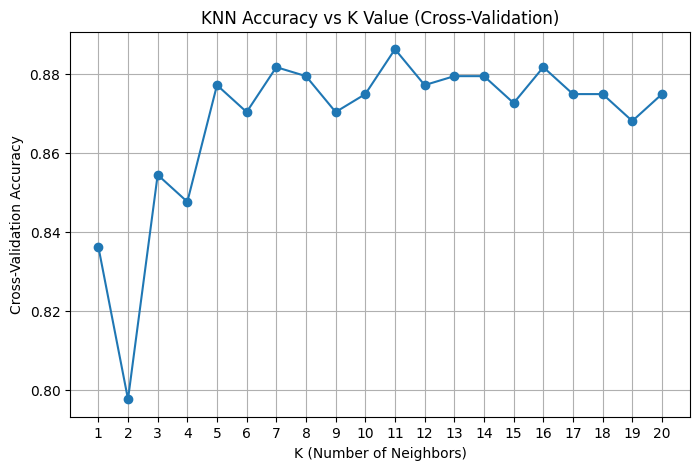

Final Test Accuracy: 0.9431818181818182

Confusion Matrix:
 [[14  0  3]
 [ 1 34  1]
 [ 0  0 35]]

Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.82      0.88        17
           2       1.00      0.94      0.97        36
           3       0.90      1.00      0.95        35

    accuracy                           0.94        88
   macro avg       0.94      0.92      0.93        88
weighted avg       0.95      0.94      0.94        88



In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Find best k using cross-validation
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    accuracies.append(cv_scores.mean())

best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)
print(f" Best k = {best_k} with Cross-Validation Accuracy = {best_acc:.4f}")

# Plot accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title("KNN Accuracy vs K Value (Cross-Validation)")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validation Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Final Model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

# Evaluation
print("Final Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
